In [106]:
import os, re
import yaml

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [107]:
RAW_PATH = os.path.join('.', '.data', 'raw')
DATASET_PATH = os.path.join('.', '.data', 'dataset')

In [108]:
data_info = yaml.load(open(os.path.join(RAW_PATH, 'raw.yaml')), yaml.SafeLoader)

names: list[str] = data_info['names']
nc: int = data_info['nc']

'# Classes: ' + str(nc), ' - '.join(names)

('# Classes: 10',
 'banded_chlorosis - brown_spot - brownrust - dried_leaves - grassy_shoot - pokkah_boeng - sett_rot - smut - viral_disease - yellow_leaf')

In [109]:
rows = list()

pattern = re.compile(r"(.+?)_(\d+)_(\d+)_jpg\.rf\.")

for img in os.listdir(os.path.join(RAW_PATH, 'images')):
    m = pattern.match(img)

    if not m:
        continue

    rows.append({
        "image_class": m.group(1), 
        "video_id": int(m.group(2)),
        "frame_id": int(m.group(3)),
        "path": img
    })

df = pd.DataFrame(rows)

df.sample(8)

,image_class,video_id,frame_id,path
2312,pokkah_boeng,3730,99,pokkah_boeng_3730_99_jpg.rf.fb2b89c6240c54d5e4...
13,sett_rot,3956,149,sett_rot_3956_149_jpg.rf.e42301471ae17db08caea...
1270,smut,4696,69,smut_4696_69_jpg.rf.7b518fb469a4a4b301ea722970...
2160,grassy_shoot,3319,103,grassy_shoot_3319_103_jpg.rf.ea4ea8667cadc3de1...
2106,grassy_shoot,3302,109,grassy_shoot_3302_109_jpg.rf.b49a77b06665f1b2f...
377,sett_rot,3989,160,sett_rot_3989_160_jpg.rf.13710c99901484781b12e...
105,brown_spot,2433,392,brown_spot_2433_392_jpg.rf.00b3ab264fe94d2c776...
2007,banded_chlorosis,1215,141,banded_chlorosis_1215_141_jpg.rf.ca82c19fcec3b...


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2357 entries, 0 to 2356
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   image_class  2357 non-null   object
 1   video_id     2357 non-null   int64 
 2   frame_id     2357 non-null   int64 
 3   path         2357 non-null   object
dtypes: int64(2), object(2)
memory usage: 73.8+ KB


In [111]:
video_class = (
    df.groupby("video_id")["image_class"]
    .agg(lambda x: x.mode()[0])
    .reset_index()
)

train_videos, temp_videos = train_test_split(
    video_class,
    test_size=0.3,
    stratify=video_class["image_class"],
    random_state=42,
)

val_videos, test_videos = train_test_split(
    temp_videos,
    test_size=0.5,
    stratify=temp_videos["image_class"],
    random_state=42,
)

train_df = df[df["video_id"].isin(train_videos["video_id"])]
val_df = df[df["video_id"].isin(val_videos["video_id"])]
test_df = df[df["video_id"].isin(test_videos["video_id"])]

In [112]:
def plot_images_distribution(df: pd.DataFrame, title: str ="Class Distribution"):
    dist_full = df["image_class"].value_counts().sort_index()
    dist_videos = df.groupby("image_class")["video_id"].nunique()

    n_plots =  2

    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5), sharey=False)

    fig.suptitle(title)

    for data, ax, title in [
        (dist_full, axes[0], "Frames"),
        (dist_videos, axes[1], "Videos"),
    ]:
        data.plot(kind="bar", ax=ax, title=title, legend=False)

        mean_val = data.mean()
        min_val = data.min()

        line_mean = ax.axhline(mean_val, color="r", linestyle="--")
        line_min  = ax.axhline(min_val,  color="g", linestyle=":")

        x_pos = len(data) - 0.25
        ax.text(x_pos, mean_val, f"{mean_val:.1f}", color="r", va="bottom", ha="left")
        ax.text(x_pos, min_val,  f"{min_val}", color="g", va="bottom", ha="left")

        ax.set_xlabel("Class")
        ax.set_ylabel("Count")

        ax.legend([line_mean, line_min], [f"mean = {mean_val:.1f}", f"min = {min_val}"])

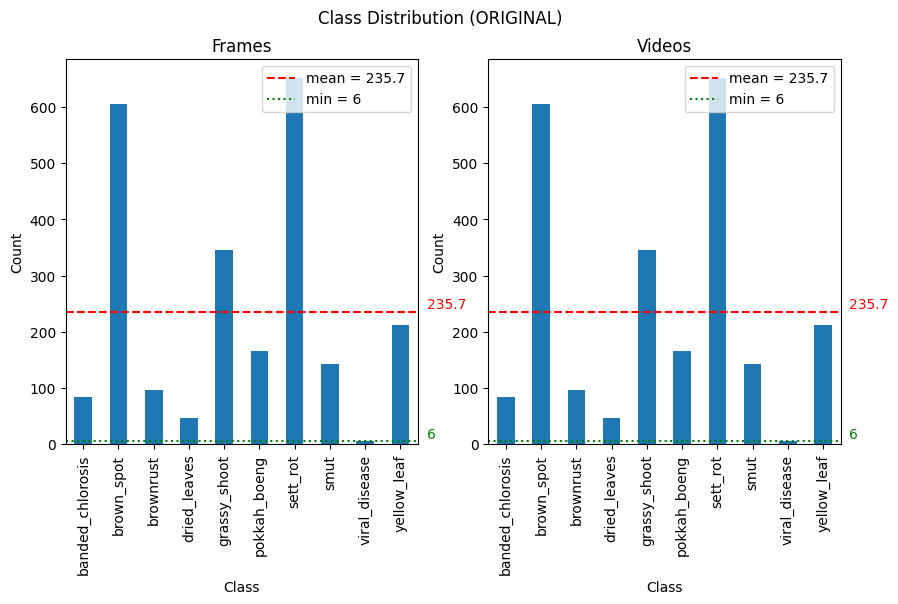

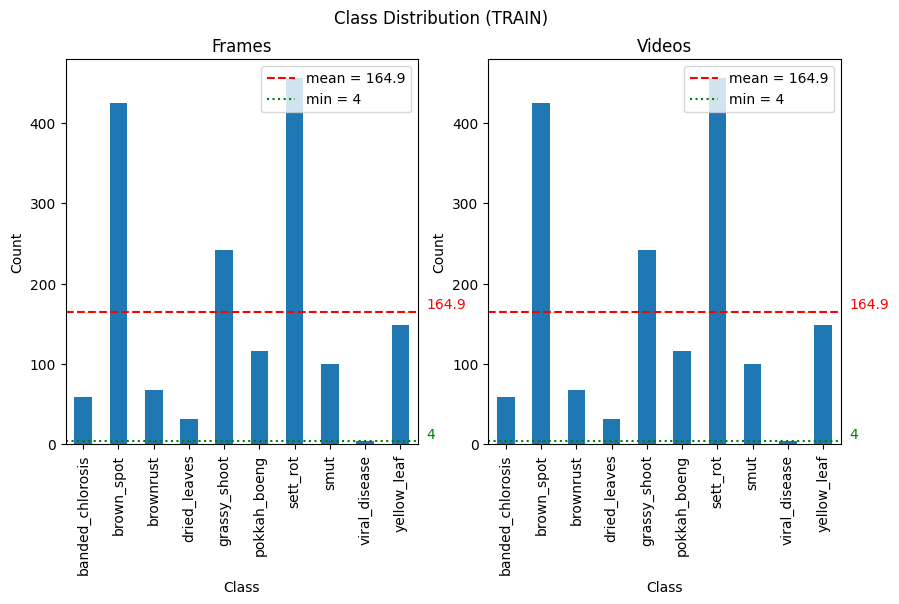

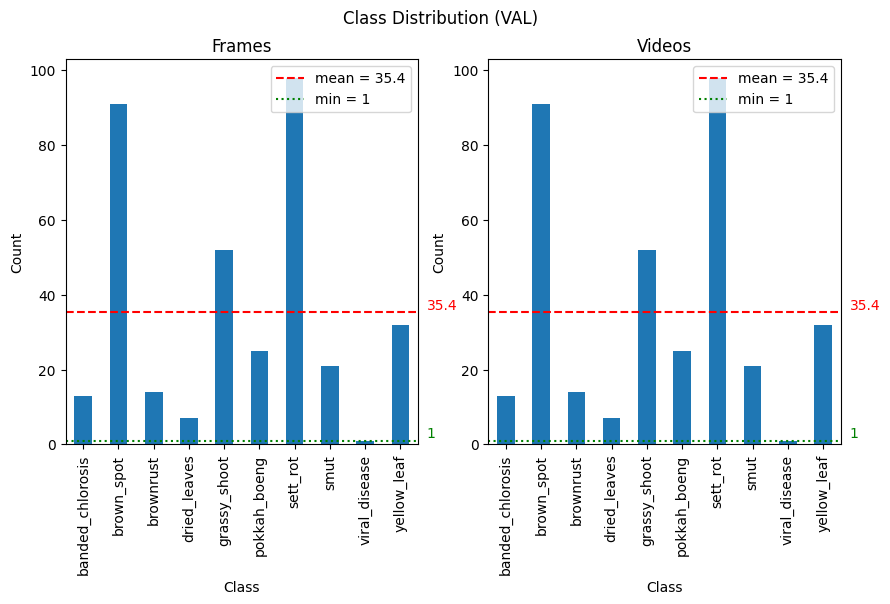

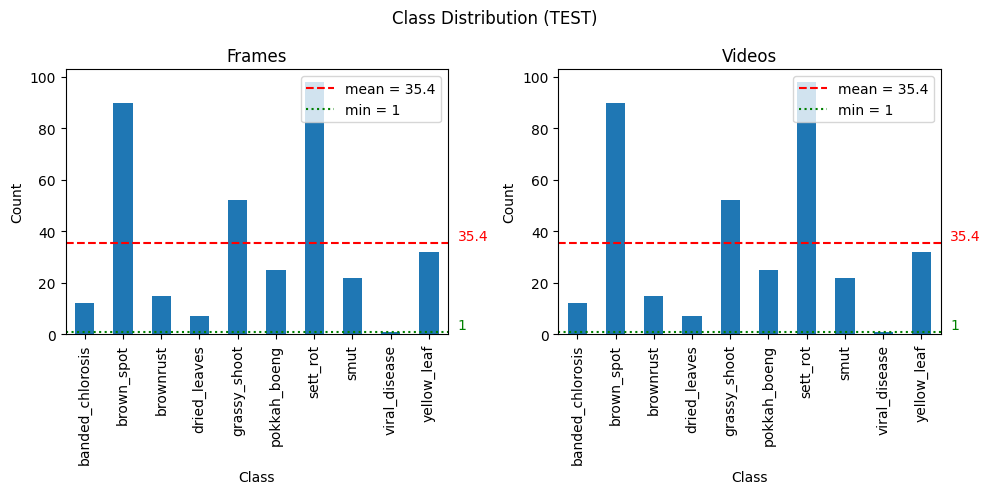

In [113]:
plot_images_distribution(df=df, title="Class Distribution (ORIGINAL)")
plot_images_distribution(df=train_df, title="Class Distribution (TRAIN)")
plot_images_distribution(df=val_df, title="Class Distribution (VAL)")
plot_images_distribution(df=test_df, title="Class Distribution (TEST)")

plt.tight_layout()
plt.show()

In [ ]:
import shutil

for n in names:
  os.makedirs(os.path.join(DATASET_PATH, "train", n), exist_ok=True)

for idx, row in train_df.iterrows():
  src = os.path.join(RAW_PATH, 'images', row['path'])
  dst = os.path.join(DATASET_PATH, "train", row['image_class'], row['path'])

  shutil.copy(src, dst) 

In [115]:
for n in names:
  os.makedirs(os.path.join(DATASET_PATH, "val", n), exist_ok=True)

for idx, row in val_df.iterrows():
  src = os.path.join(RAW_PATH, 'images', row['path'])
  dst = os.path.join(DATASET_PATH, "val", row['image_class'], row['path'])

  shutil.copy(src, dst) 

In [116]:
for n in names:
  os.makedirs(os.path.join(DATASET_PATH, "test", n), exist_ok=True)

for idx, row in test_df.iterrows():
  src = os.path.join(RAW_PATH, 'images', row['path'])
  dst = os.path.join(DATASET_PATH, "test", row['image_class'], row['path'])

  shutil.copy(src, dst) 